# ARENA environment check

Use **Run → Run All Cells**. This checks the active Python, GPU, gradients, and two visualizations without downloading models or calling APIs.

[Back to the catalog](README.md) · [Your study plan](../LEARNING_PLAN.md)

In [1]:
from pathlib import Path
import runpy
workspace = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "arena" / "runtime.py").is_file())
globals().update(runpy.run_path(str(workspace / "arena" / "runtime.py"))["setup"]("chapter1_transformer_interp", "part1_transformer_from_scratch"))

ARENA local setup: chapter1_transformer_interp / part1_transformer_from_scratch
Python 3.12.14 | PyTorch 2.8.0+cu128 | NVIDIA GeForce RTX 5070 Ti
Exercise blanks are intentional. Paid API sections are manual; see arena/README.md.


In [2]:
import sys
import torch
print("Interpreter:", sys.executable)
assert torch.cuda.is_available(), "The ARENA GPU kernel should see your GPU."
x = torch.randn(64, 64, device="cuda", requires_grad=True)
loss = (x @ x.T).square().mean()
loss.backward()
assert torch.isfinite(x.grad).all()
print("PASS: GPU calculation and gradients.")

Interpreter: C:\Users\willi\Desktop\learning\Mech Interp\arena\.venv\Scripts\python.exe
PASS: GPU calculation and gradients.


## Plotly

A green heatmap should appear below. Hover over a square to see its values.

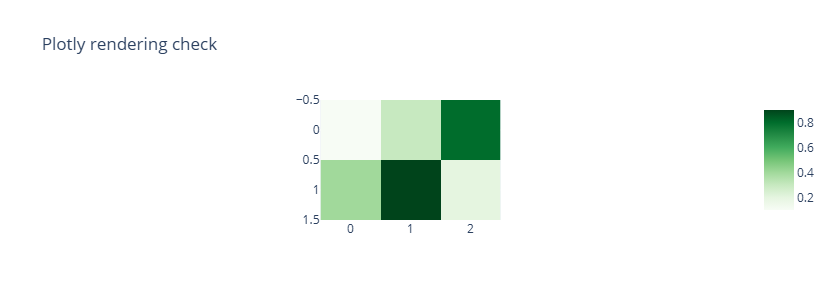

In [3]:
import plotly.express as px
px.imshow([[0.1, 0.3, 0.8], [0.4, 0.9, 0.2]], color_continuous_scale="Greens", title="Plotly rendering check", height=300).show()

## CircuitsVis

A small attention diagram should appear. This is synthetic display data for checking the renderer.

In [4]:
import circuitsvis as cv
from IPython.display import display
pattern = torch.eye(4).unsqueeze(0)
display(cv.attention.attention_patterns(tokens=["one", "two", "three", "four"], attention=pattern))